|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|



### Probleme 10B18


Le réacteur catalytique a 3 sections, seule la section du milieu a une source thermique
<img src='http:\\pierreproulx.pheno.ca\prob-10-B-18.png'>
La solution est identique à celle de la section 10.5, la seule différence est de remplacer S par $ S*T_2 $

Les profils de température ne sont pas aussi différents de ceux que l'on a calculé dans la section 10.5 par rapport au texte, rappelons qu'on n'avait pas négligé les termes de conduction, contrairement à Bird. Les expressions obtenues deviennent extrêmement lourdes, mais *SYMPY* fait le travail pour nous et le travail de mise en place des équations est exactement le même.

In [1]:
#
# Pierre Proulx
#
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# Paramètres, variables et fonctions, on utilise directement les équations définies
# plus haut
#
rho,c_p,v_0,k_eff,S,z=sp.symbols('rho,c_p,v_0,k_eff,S,z')                                                            
T_1=sp.Function('T_1')(z)
T_2=sp.Function('T_2')(z)
T_3=sp.Function('T_3')(z)
eq1=sp.Eq(k_eff*sp.diff(T_1,z,z)-rho*c_p*v_0*sp.diff(T_1,z),0)
eq2=sp.Eq(k_eff*sp.diff(T_2,z,z)-rho*c_p*v_0*sp.diff(T_2,z)+S*T_2,0)
eq3=sp.Eq(k_eff*sp.diff(T_3,z,z)-rho*c_p*v_0*sp.diff(T_3,z),0)
T_1=sp.dsolve(eq1,T_1).rhs
T_2=sp.dsolve(eq2,T_2).rhs  # rhs pour avoir seulement a droite de l'égalité
T_3=sp.dsolve(eq3,T_3).rhs
#
# Renommer les constantes C1 et C2 dans les équations 2 et 3
#
T_2=T_2.subs(sp.symbols('C1'),sp.symbols('C3'))
T_2=T_2.subs(sp.symbols('C2'),sp.symbols('C4'))
T_3=T_3.subs(sp.symbols('C1'),sp.symbols('C5'))
T_3=T_3.subs(sp.symbols('C2'),sp.symbols('C6'))

In [3]:
#
# On peut calculer les flux de Fourier 
#
q_1 =-k_eff*sp.diff(T_1,z)
q_2 =-k_eff*sp.diff(T_2,z)
q_3 =-k_eff*sp.diff(T_3,z)

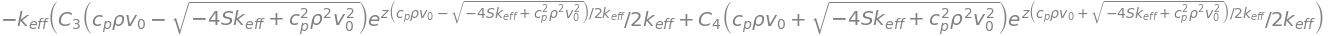

In [4]:
# écrivons les équations de base qui seront utilisées, au besoin
display(T_1)
display(T_2)
display(T_3)
display(q_1)
display(q_2)
display(q_3)

In [ ]:
# Les conditions aux limites, 6 équations car 6 inconnues.
#
# En z=0, T1 est la valeur d'entrée, T0
T_0,z_1,z_2=sp.symbols('T_0,z_1,z_2')
CL1=T_1.subs(z,0)-T_0
# En z=z1, la température des deux milieux sont égales     T_1(z1) = T_2(z1)
CL2=T_1.subs(z,z_1)-T_2.subs(z,z_1)
# en z=z1, le flux des deux milieux sont égaux             q_1(z1) = q_2(z1)
CL3=q_1.subs(z,z_1)-q_2.subs(z,z_1)
# en z=z2,  la température des deux milieux sont égales    T_2(z2) = T_3(z2)
CL4=T_2.subs(z,z_2)-T_3.subs(z,z_2)
# en z=z2, le flux des deux milieux sont égaux             q_2(z2) = q_2(z2)
CL5=q_2.subs(z,z_2)-q_3.subs(z,z_2)
# en z=infini, le flux est nul                               q_3(infini) = 0
CL6=q_3.subs((z,sp.oo),0)
constantes=sp.solve([CL1,CL2,CL3,CL4,CL5,CL6]
                    ,sp.symbols('C1,C2,C3,C4,C5,C6'))
#display(constantes)
T_1=T_1.subs(constantes)
T_2=T_2.subs(constantes)
T_3=T_3.subs(constantes)
q_1=q_1.subs(constantes)
q_2=q_2.subs(constantes)
q_3=q_3.subs(constantes)
display('T_1',T_1)
display('T_2',T_2)
display('T_3',T_3)
display('q_1',q_1)
display('q_2',q_2)
display('q_3',q_3)

In [ ]:
#
# On utilise des valeurs supposées pour obtenir des profils réalistes
# La première série de graphes est avec une conductivité thermique plus faible
#
dico1={'rho':1,'c_p':1000,'z_1':1,'z_2':2,'k_eff':1,'v_0':.005,'S':3,'T_0':293}
dico2={'rho':1,'c_p':1000,'z_1':1,'z_2':2,'k_eff':2,'v_0':.005,'S':3,'T_0':293}
T_1plot=T_1.subs(dico1)
T_2plot=T_2.subs(dico1)
T_3plot=T_3.subs(dico1)
T_12plot=T_1.subs(dico2)
T_22plot=T_2.subs(dico2)
T_32plot=T_3.subs(dico2)
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=10,8
sp.plot((T_1plot,(z,0,1)),(T_2plot,(z,1,2)),(T_3plot,(z,2,3)),
       (T_12plot,(z,0,1)),(T_22plot,(z,1,2)),(T_32plot,(z,2,3)));